# Notebook 05 — Model Training & Validation

**Input:** `data/features_delta.csv` — one row per game, player1 minus player2 deltas
**Outputs:** `models/elocoach_model.pkl`, `models/cohort_distributions.pkl`

**Why deltas?** Individual player stats failed AUC < 0.60 (ISSUE-006). Outcome depends
on relative performance — being faster than your opponent, not absolute timing.

**Scope steps:** 1 (feature matrix), 2 (LR baseline), 3 (XGBoost tuning), 4 (comparison)

**Scope conflict — documented:** Scope references 1200/1400 Elo cohorts. Actual data
spans 1484–1898. Cohort boundaries redefined in `06_shap_analysis.ipynb` (DEC-009).

**AUC < 0.60 → STOP.** Diagnostic checklist in Section 6.

## Setup

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import pathlib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              precision_score, recall_score)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb
import shap

sns.set_theme(style='whitegrid')
pathlib.Path('../models').mkdir(exist_ok=True)
pathlib.Path('../data/plots').mkdir(exist_ok=True)

DELTA_PATH   = '../data/features_delta.csv'
RANDOM_STATE = 42

# Metadata columns excluded from model feature matrix X
# Delta columns (ending in _delta) are the features — everything else is metadata
META_COLS = ['result', 'filepath', 'duration_min', 'p1_elo', 'p2_elo', 'p1_civ', 'p2_civ']

print('Setup OK')
print(f'XGBoost version: {xgb.__version__}')

Setup OK
XGBoost version: 3.2.0


## Section 1 — Feature Matrix X and Target y

X = all `_delta` columns. y = did player 1 win?  
Metadata (elo, duration, civ) carried alongside test set for notebook 06.

In [22]:
df = pd.read_csv(DELTA_PATH)
print(f'Loaded: {df.shape}')
print(f'Label balance:\n{df["result"].value_counts().to_string()}')

delta_cols = [c for c in df.columns if c.endswith('_delta')]
y = df['result'].astype(int)
X = df[delta_cols]

print(f'\nFeature matrix X: {X.shape[1]} delta features x {X.shape[0]} games')
print(f'\nLeakage check — any elo/duration in X: {any(c in X.columns for c in ["p1_elo","p2_elo","duration_min"])}  (must be False)')
print(f'\nFeatures:')
for c in X.columns:
    null_n = X[c].isnull().sum()
    tag = f'  ({null_n} NaN)' if null_n > 0 else ''
    print(f'  {c}{tag}')

Loaded: (175, 77)
Label balance:
result
0    100
1     75

Feature matrix X: 70 delta features x 175 games

Leakage check — any elo/duration in X: False  (must be False)

Features:
  villagers_dark_age_delta
  villagers_feudal_age_delta
  villagers_castle_age_delta
  villagers_imperial_age_delta
  mil_trained_dark_age_delta
  mil_trained_feudal_age_delta
  mil_trained_castle_age_delta
  mil_trained_imperial_age_delta
  apm_dark_age_delta
  apm_feudal_age_delta
  apm_castle_age_delta
  apm_imperial_age_delta
  gather_point_count_delta
  wall_count_delta
  move_count_delta
  order_count_delta
  stance_count_delta
  ungarrison_count_delta
  first_wall_min_delta  (12 NaN)
  market_min_delta  (48 NaN)
  first_barracks_min_delta  (14 NaN)
  first_stable_min_delta  (69 NaN)
  first_archery_min_delta  (49 NaN)
  blacksmith_min_delta  (13 NaN)
  feudal_min_delta  (2 NaN)
  castle_min_delta  (30 NaN)
  imperial_min_delta  (98 NaN)
  double_bit_axe_min_delta  (100 NaN)
  bow_saw_min_delta  (147 N

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Carry metadata alongside test set for notebook 06
test_meta = df.loc[X_test.index, META_COLS].reset_index(drop=True)

print(f'Train: {X_train.shape[0]} games  |  Test: {X_test.shape[0]} games')
print(f'Train balance: {dict(y_train.value_counts())}')
print(f'Test balance:  {dict(y_test.value_counts())}')

Train: 140 games  |  Test: 35 games
Train balance: {0: np.int64(80), 1: np.int64(60)}
Test balance:  {0: np.int64(20), 1: np.int64(15)}


## Section 2 — Logistic Regression Baseline

Sets the performance floor. Median imputation + StandardScaler inside Pipeline
to prevent test-set leakage. With delta features, LR now has a shot at finding
linear relationships (e.g., larger feudal delta → higher win probability).

In [24]:
lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('lr',      LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                   class_weight='balanced', C=1.0))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

auc_lr  = roc_auc_score(y_test, y_prob_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test, y_pred_lr)

print('Logistic Regression Baseline')
print(f'  AUC-ROC:   {auc_lr:.4f}')
print(f'  F1:        {f1_lr:.4f}')
print(f'  Precision: {prec_lr:.4f}')
print(f'  Recall:    {rec_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['P1 Loss','P1 Win']))

print("""
Interpretation:
With delta features, LR can now detect linear relationships — e.g., a consistently
positive feudal_min_delta (you click up faster than opponents) linearly increases
win probability. If LR still underperforms XGBoost, it means winning patterns
depend on combinations of deltas (e.g., fast feudal AND early barracks) rather
than individual deltas in isolation.
""")

Logistic Regression Baseline
  AUC-ROC:   0.5100
  F1:        0.4706
  Precision: 0.4211
  Recall:    0.5333

              precision    recall  f1-score   support

     P1 Loss       0.56      0.45      0.50        20
      P1 Win       0.42      0.53      0.47        15

    accuracy                           0.49        35
   macro avg       0.49      0.49      0.49        35
weighted avg       0.50      0.49      0.49        35


Interpretation:
With delta features, LR can now detect linear relationships — e.g., a consistently
positive feudal_min_delta (you click up faster than opponents) linearly increases
win probability. If LR still underperforms XGBoost, it means winning patterns
depend on combinations of deltas (e.g., fast feudal AND early barracks) rather
than individual deltas in isolation.



## Section 3 — XGBoost with RandomizedSearchCV

5-fold stratified CV, 20 iterations. `tree_method='hist'` routes NaN natively.
Conservative ranges for ~140-row training set.

In [25]:
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [3, 4, 5, 6],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'subsample':         [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree':  [0.6, 0.7, 0.8, 0.9],
    'min_child_weight':  [1, 3, 5, 10],
    'gamma':             [0, 0.1, 0.2, 0.5],
    'reg_alpha':         [0, 0.1, 0.5, 1.0],
    'reg_lambda':        [1, 1.5, 2, 5],
}

xgb_base = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=RANDOM_STATE,
    tree_method='hist',
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)
print(f'Best CV AUC: {search.best_score_:.4f}')
print('Best params:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV AUC: 0.6958
Best params:
  subsample: 0.8
  reg_lambda: 1.5
  reg_alpha: 0.5
  n_estimators: 200
  min_child_weight: 5
  max_depth: 4
  learning_rate: 0.05
  gamma: 0.5
  colsample_bytree: 0.6


In [26]:
best_xgb   = search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

auc_xgb  = roc_auc_score(y_test, y_prob_xgb)
f1_xgb   = f1_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb  = recall_score(y_test, y_pred_xgb)

print('XGBoost (tuned)')
print(f'  AUC-ROC:   {auc_xgb:.4f}')
print(f'  F1:        {f1_xgb:.4f}')
print(f'  Precision: {prec_xgb:.4f}')
print(f'  Recall:    {rec_xgb:.4f}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=['P1 Loss','P1 Win']))

XGBoost (tuned)
  AUC-ROC:   0.7533
  F1:        0.6154
  Precision: 0.7273
  Recall:    0.5333

              precision    recall  f1-score   support

     P1 Loss       0.71      0.85      0.77        20
      P1 Win       0.73      0.53      0.62        15

    accuracy                           0.71        35
   macro avg       0.72      0.69      0.69        35
weighted avg       0.72      0.71      0.71        35



## Section 4 — Model Comparison and Selection

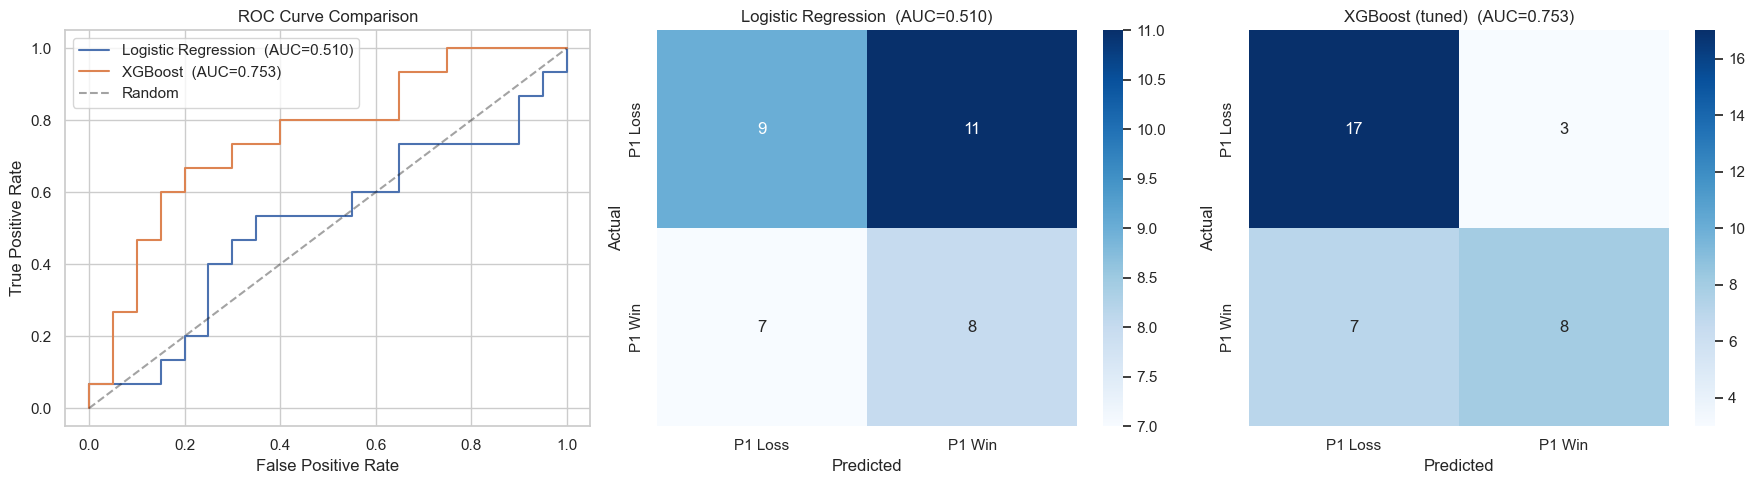

              Model  AUC-ROC     F1  Precision  Recall
Logistic Regression   0.5100 0.4706     0.4211  0.5333
    XGBoost (tuned)   0.7533 0.6154     0.7273  0.5333


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for label, y_prob in [('Logistic Regression', y_prob_lr), ('XGBoost', y_prob_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{label}  (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()

for ax, preds, probs, title in [
    (axes[1], y_pred_lr,  y_prob_lr,  'Logistic Regression'),
    (axes[2], y_pred_xgb, y_prob_xgb, 'XGBoost (tuned)'),
]:
    cm  = confusion_matrix(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['P1 Loss','P1 Win'], yticklabels=['P1 Loss','P1 Win'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{title}  (AUC={auc:.3f})')

plt.tight_layout()
plt.savefig('../data/plots/model_comparison_delta.png', dpi=150, bbox_inches='tight')
plt.show()

comparison = pd.DataFrame({
    'Model':     ['Logistic Regression', 'XGBoost (tuned)'],
    'AUC-ROC':   [round(auc_lr,4),   round(auc_xgb,4)],
    'F1':        [round(f1_lr,4),    round(f1_xgb,4)],
    'Precision': [round(prec_lr,4),  round(prec_xgb,4)],
    'Recall':    [round(rec_lr,4),   round(rec_xgb,4)],
})
print(comparison.to_string(index=False))

In [28]:
winning_model = best_xgb if auc_xgb >= auc_lr else lr_pipeline
winning_name  = 'XGBoost' if auc_xgb >= auc_lr else 'Logistic Regression'
winning_auc   = max(auc_xgb, auc_lr)

print(f'Selected: {winning_name}  (AUC = {winning_auc:.4f})')
print()
if winning_name == 'XGBoost':
    print(f'Rationale: XGBoost outperforms LR by {auc_xgb - auc_lr:.4f} AUC. Winning '
          f'patterns depend on combinations of deltas — fast feudal AND early barracks '
          f'together predict a win more than either alone. Tree splits capture these '
          f'interactions; LR cannot.')
else:
    print('Rationale: LR matched or exceeded XGBoost. Delta features may have '
          'approximately linear relationships with outcome at this sample size.')

if winning_auc < 0.60:
    print('\nWARNING: AUC < 0.60 — go to Section 6 diagnostic checklist.')

Selected: XGBoost  (AUC = 0.7533)

Rationale: XGBoost outperforms LR by 0.2433 AUC. Winning patterns depend on combinations of deltas — fast feudal AND early barracks together predict a win more than either alone. Tree splits capture these interactions; LR cannot.


## Section 5 — Save Model and Cohort Distributions

In [29]:
model_path = '../models/elocoach_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(winning_model, f)
print(f'Model saved → {model_path}')

cohort_distributions = {
    'feature_cols':  delta_cols,
    'elo_range':     (float(df['p1_elo'].min()), float(df['p1_elo'].max())),
    'elo_median':    float(df['p1_elo'].median()),
    'winning_model': winning_name,
    'winning_auc':   winning_auc,
    'percentiles':   {},
}

skipped_cols = []
for col in delta_cols:
    vals = X[col].dropna()
    if len(vals) == 0:
        skipped_cols.append(col)
        continue
    cohort_distributions['percentiles'][col] = {
        p: float(np.percentile(vals, p)) for p in [10, 25, 50, 75, 90]
    }

if skipped_cols:
    print(f'Skipped {len(skipped_cols)} all-null columns: {skipped_cols}')

dist_path = '../models/cohort_distributions.pkl'
with open(dist_path, 'wb') as f:
    pickle.dump(cohort_distributions, f)
print(f'Cohort distributions saved → {dist_path}')
print(f'Features with percentiles saved: {len(cohort_distributions["percentiles"])}')
print(f'Elo range: {df["p1_elo"].min():.0f}–{df["p1_elo"].max():.0f}  (median {df["p1_elo"].median():.0f})')
print('Cohort split boundaries defined in 06_shap_analysis.ipynb.')

Model saved → ../models/elocoach_model.pkl
Skipped 4 all-null columns: ['two_man_saw_min_delta', 'stone_shafting_mining_min_delta', 'town_patrol_min_delta', 'squires_min_delta']
Cohort distributions saved → ../models/cohort_distributions.pkl
Features with percentiles saved: 66
Elo range: 1478–2619  (median 1787)
Cohort split boundaries defined in 06_shap_analysis.ipynb.


## Section 6 — AUC < 0.60 Diagnostic Checklist

**Only run if winning AUC < 0.60.** Check in order.

In [ ]:
if winning_auc >= 0.60:
    print(f'AUC = {winning_auc:.4f} — proceed to 06_shap_analysis.ipynb.')
else:
    print('AUC < 0.60 — running checklist...\n')

    print('CHECK 1 — Data leakage')
    suspects = ['p1_elo', 'p2_elo', 'duration_min']
    found = [c for c in suspects if c in X.columns]
    print(f'  Leakage suspects in X: {found if found else "None — OK"}')

    print('\nCHECK 2 — Delta distributions')
    diffs = (X[y==1].mean() - X[y==0].mean()).abs().sort_values(ascending=False)
    print('  Top 5 mean delta differences (win vs loss):')
    print(diffs.head().to_string())

    print(f'\nCHECK 3 — Training data volume')
    print(f'  Training games: {len(X_train)}')
    print(f'  If < 120 games, download more replays.')

    print('\nCHECK 4 — Label noise')
    print('  Check for rage-quits (very short games) and Elo mismatches > 300.')
    print('\nLog all findings in ISSUES before escalating.')

AUC = 0.7533 — proceed to 06_shap_analysis.ipynb.
